# Testing Sparse Auto Encoder (SAE)

In principal, it should be possible to extract hidden feature vectors from embedding outputs using a sparse auto-encoder (SAE) to disentangle the superimposed features for a given set of neural activation outputs. To test the validity of using a SAE for this purpose, the code below trains one on some randomized vectors to assess whether the methods described in literature are enough to create sparsity in the feature layer of a 2-layer autoencoder.

In [1]:
# imports
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import pandas as pd
import Bio
import transformers
from objects.autoencoder import SparseAutoEncoder
import os

# data vis packages
import seaborn as sns
import matplotlib.pyplot as plt

2024-11-14 09:53:56.716611: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-14 09:53:56.881432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731599636.960438   28811 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731599636.983962   28811 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-14 09:53:57.158647: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Train the Model

In [2]:
# create dataset from random tensors to test
SAE_name = 'autoencoder_test'
embed_length = 2048
ef = 4

print("=== Generating Test Data ===")
fake_embeddings = tf.random.uniform(shape=[10000, embed_length])
fake_dataset = tf.data.Dataset.from_tensor_slices((fake_embeddings, fake_embeddings)).batch(100)

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.KLDivergence(),
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

print(autoencoder.summary())

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(fake_dataset, epochs=100, callbacks=[tb_callback, early_stopping])
print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'
#autoencoder.save(f'./models/{SAE_name}.keras')
keras.models.save_model(autoencoder, path)
print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Generating Test Data ===
=== Initializing Model ===


I0000 00:00:1731599640.542980   28811 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6213 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sparse_auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 100,700,162 (384.14 MB)

 Trainable params: 33,566,720 (128.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,133,442 (256.09 MB)

None


### Examine Weights and their Distribution

Note that in a real use case we would expect most features to have relatively low weights (roughly corresponding to the feature's importance), however, in this case we observe a somewhat sine-like distribution with a bit of decay. I suspect this is due to the process of random number generation, but further analysis would be warranted before asserting that claim.

As a note to myself, the concept of superposition shares a lot of common principles with slit experiments and waves so this particular graph might actually warrant some further investigation from a purely mathematical standpoint. 

In [3]:
feat_weights = np.array(autoencoder.weights[2])
print(f"maximum: {max(feat_weights)}")
print(f"minimum: {min(feat_weights)}")

maximum: -0.022541893646121025
minimum: -0.2633558511734009


/tmp/ipykernel_28811/1965811903.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  feat_weights = np.array(autoencoder.weights[2])


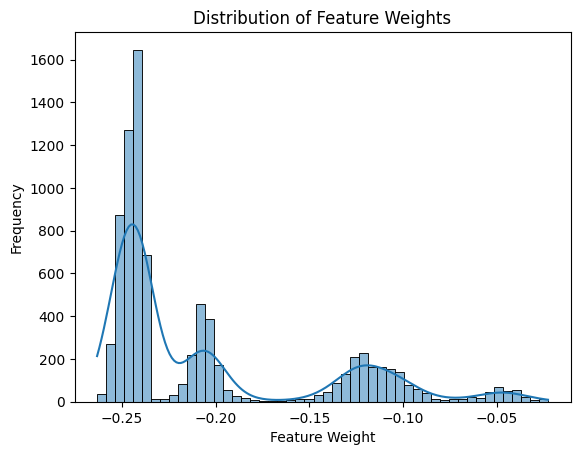

In [4]:
sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Examining Feature Layer for Sparsity

In [5]:
autoencoder.predict_on_batch(fake_embeddings[:100])

(array([[0.4789736 , 0.48172942, 0.4855742 , ..., 0.4853218 , 0.50022686,
         0.47568583],
        [0.48064056, 0.48559248, 0.48935565, ..., 0.48831168, 0.50534827,
         0.47833622],
        [0.4818014 , 0.48718905, 0.49121693, ..., 0.489812  , 0.5084133 ,
         0.47970536],
        ...,
        [0.48230228, 0.48942813, 0.49291715, ..., 0.49138883, 0.512046  ,
         0.4813877 ],
        [0.48394576, 0.4927162 , 0.4960518 , ..., 0.4936572 , 0.5168512 ,
         0.48366895],
        [0.48255748, 0.4889506 , 0.49297288, ..., 0.49113655, 0.5115662 ,
         0.48141354]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [6]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(fake_embeddings[:100])

In [7]:
reconstructed_outputs

array([[0.4789736 , 0.48172942, 0.4855742 , ..., 0.4853218 , 0.50022686,
        0.47568583],
       [0.48064056, 0.48559248, 0.48935565, ..., 0.48831168, 0.50534827,
        0.47833622],
       [0.4818014 , 0.48718905, 0.49121693, ..., 0.489812  , 0.5084133 ,
        0.47970536],
       ...,
       [0.48230228, 0.48942813, 0.49291715, ..., 0.49138883, 0.512046  ,
        0.4813877 ],
       [0.48394576, 0.4927162 , 0.4960518 , ..., 0.4936572 , 0.5168512 ,
        0.48366895],
       [0.48255748, 0.4889506 , 0.49297288, ..., 0.49113655, 0.5115662 ,
        0.48141354]], dtype=float32)

In [8]:
feature_outputs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [9]:
feature_outputs[0].sort()
print(feature_outputs[0][-20:])
print(feature_outputs.shape)

[0.02374375 0.02385363 0.02390049 0.024161   0.02436854 0.02442607
 0.02446233 0.02450757 0.02469315 0.02569892 0.0259524  0.02610183
 0.02683616 0.02724424 0.02806582 0.02806839 0.02840419 0.03062022
 0.03885876 0.0473991 ]
(100, 8192)


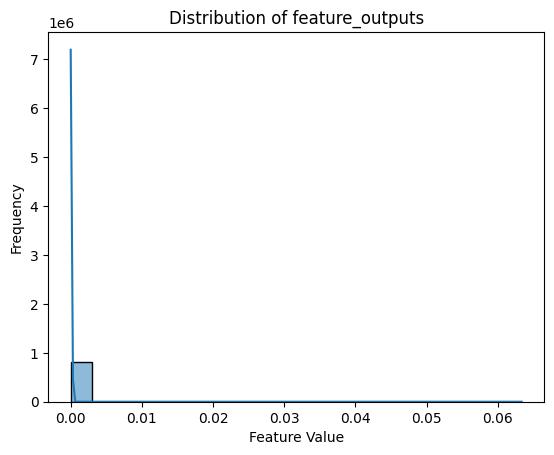

In [10]:
sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

### Check Model Fit / Overfit

In [11]:
# check model fit
fit_test_data = tf.random.uniform(shape=[100, embed_length])
fit_test_dataset = tf.data.Dataset.from_tensor_slices((fit_test_data, fit_test_data)).batch(10)

fit_test = autoencoder.evaluate(fit_test_dataset)
print(f"Loss: {fit_test[0]} | MSE: {fit_test[1]}")

2024-11-14 09:54:48.949745: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47_0', 828 bytes spill stores, 1256 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 180.7134 - mean_squared_error: 0.0834  
Loss: 180.71429443359375 | MSE: 0.08356717973947525


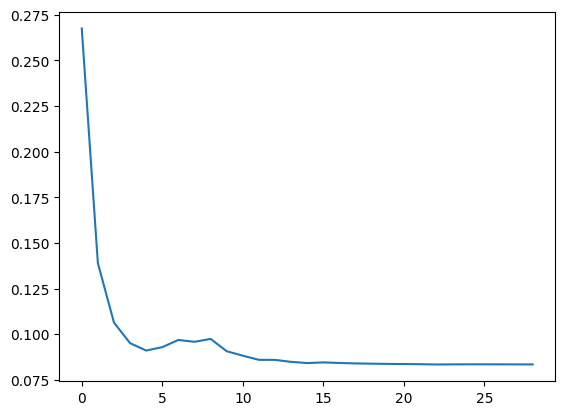

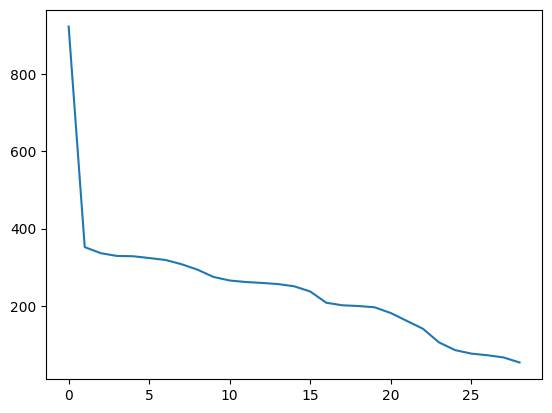

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['mean_squared_error'])
plt.show()
plt.plot(history.history['loss'])
plt.show()

# With the ESM Embeddings

In [13]:
# load metadata
var_data = pd.read_csv('./data/hbvar-w-func-embed-seq.csv')
# pandas saves these as strings for some reason - reload from numpy
var_data = pd.DataFrame(var_data['sequence'])

# explicitly match embeddings to sequences when re-loading
embeddings = [np.load(f"./data/variant_embeddings/all_vars/{j}.npy") for j in var_data["sequence"]]

# reduce jagged tensors and add to dataframe
def fix_jagged_2d(embed_list):
    sir_gallahad_the_chaste = []
    # find max length in 2nd dim (sequence length)
    max_len = max([len(arr[0]) for arr in embed_list])
    # append zero vector to embeddings
    for i, arr in enumerate(embed_list):
        if len(arr[0]) < max_len:
            padded = np.append(arr[0], np.zeros((max_len - len(arr[0]), 1280)), axis=0)
            sir_gallahad_the_chaste.append(np.expand_dims(padded, axis=0))
        else:
            sir_gallahad_the_chaste.append(arr)
    return sir_gallahad_the_chaste

embeddings = np.concatenate(fix_jagged_2d(embeddings))
var_data['embeddings'] = embeddings
print(embeddings.shape)

(1206, 148, 1280)


In [16]:
np.stack(np.unstack(embeddings, axis=2)).shape

: 

In [15]:
embeddings.shape

(1206, 148, 1280)